## module 3f — curated design (iteration 5)

15's model scored 0.88 on our metric suite. redrawn the way a landscape architect
draws — one labeled patch per mass — that 0.88 plan turned out to be a wall-to-wall
groundcover carpet with seven scattered plants. nobody would plant it. the metrics
were satisfied because we wrote them; best-of-48 argmax then amplified exactly the
plans that game them (reward overoptimization, Gao et al. 2023).

this iteration is the correction, driven by *looking at outputs*:

1. **genre reframe** — real planting plans draw the *design layer*: ~35 symbols,
   ~8 species, ~13 masses, anchors + rhythm + negative space (measured from the
   size-matched harvested permapeople beds). the horticultural fill (15's carpets)
   becomes a planting note, not 40 circles. `gen_plan4` composes that layer:
   rule-of-thirds structural anchor, theme species repeated as three masses,
   height-banded secondaries, front accents, a few specimen singles.
2. **honest evaluation** — the primary number is `realism`: distance to the real
   beds' design statistics (species count, mass count/size, singles share,
   density), which we did not author. the old `score3` is reported but never
   optimized. final judgment: blinded pairwise sheets for human ranking.
3. **simplifications** — count tokens dropped from the canvas (soft twice measured:
   0.72 in 13, 3.45 in 15 — slot pins are the mechanism); sequence shrinks
   354 → 147 tokens; the drawing (`show_plan4`) is now a designer's patch plan.

runtime: ~15 min corpus + ~10 min training on a small gpu, checkpointed
(`checkpoints/garden_maskdiff4_{last,best}.pt`).

In [1]:
# get bvtrain (shared plumbing): locally it's ../bvtrain; on colab/kaggle clone the repo
import os, sys
_CANDS = ["..", ".", "botanical-vision"]
if not any(os.path.isdir(f"{p}/bvtrain") for p in _CANDS):
    os.system("git clone -q https://github.com/babnigg/botanical-vision")
sys.path[:0] = [p for p in _CANDS if os.path.isdir(f"{p}/bvtrain")]

import hashlib, json, math, random
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm, trange

from bvtrain import garden as g

SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEV = "cuda" if torch.cuda.is_available() else "cpu"
plt.rcParams["figure.facecolor"] = "linen"
DEV

'cuda'

### exhibit: how 15's champion fooled its own metrics

the same maskdiff3 plan drawn both ways. left: the circle view we were looking at.
right: the designer's view — a phlox carpet, seven plants, no design. `score3` said
0.88. this cell is the reason iteration 5 exists (skipped if the old checkpoint
isn't on disk).

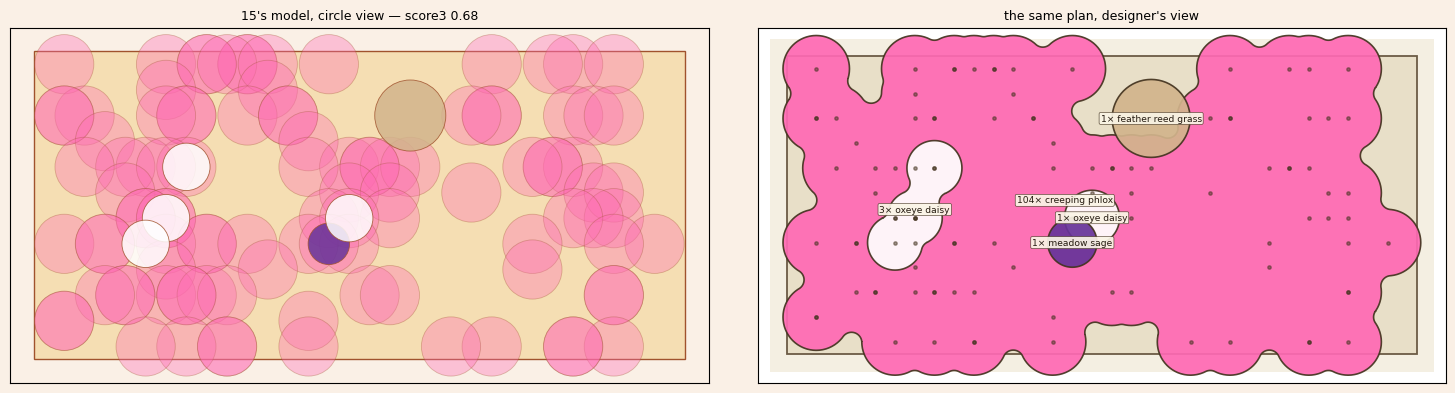

In [2]:
OLD = g.ckpt_dir() / "garden_maskdiff3_best.pt"
if OLD.exists():
    # minimal maskdiff3 decode setup (matches nb 15's token scheme)
    NX3, NY3, NW3, ND3, NCNT3, NSP3, MAXP3 = 32, 12, 9, 7, 10, len(g.PALETTE), 110
    T_W3 = 1; T_D3 = T_W3 + NW3; T_SUN3 = T_D3 + ND3; T_CNT3 = T_SUN3 + 3
    T_SP3 = T_CNT3 + NCNT3; T_X3 = T_SP3 + 1 + NSP3; T_Y3 = T_X3 + 1 + NX3
    VOCAB3 = T_Y3 + 1 + NY3; L3 = 3 + NSP3 + 3 * MAXP3

    class MDM3(nn.Module):
        def __init__(self, v=VOCAB3, dm=192, heads=6, layers=6, ctx=L3):
            super().__init__()
            self.tok = nn.Embedding(v, dm); self.pos = nn.Embedding(ctx, dm)
            blk = nn.TransformerEncoderLayer(dm, heads, dm * 4, dropout=0.1,
                                             batch_first=True, norm_first=True)
            self.tf = nn.TransformerEncoder(blk, layers, enable_nested_tensor=False)
            self.head = nn.Linear(dm, v)
        def forward(self, x):
            h = self.tok(x) + self.pos(torch.arange(x.shape[1], device=x.device))
            return self.head(self.tf(h))

    m3 = MDM3().to(DEV)
    m3.load_state_dict(torch.load(OLD, map_location=DEV, weights_only=False)["model"])
    m3.eval()
    fam3 = ([(T_W3, T_D3), (T_D3, T_SUN3), (T_SUN3, T_CNT3)] + [(T_CNT3, T_SP3)] * NSP3
            + [(T_SP3, T_X3), (T_X3, T_Y3), (T_Y3, VOCAB3)] * MAXP3)
    FM3 = torch.full((L3, VOCAB3), float("-inf"))
    for p_, (lo, hi) in enumerate(fam3):
        FM3[p_, lo:hi] = 0
    FM3 = FM3.to(DEV)

    @torch.no_grad()
    def sample3(w, d, sun, steps=12):
        site = [T_W3 + min(NW3 - 1, int((w - 3.5) / .5)),
                T_D3 + min(ND3 - 1, int((d - 1.8) / .2)), T_SUN3 + sun]
        canvas = torch.zeros(1, L3, dtype=torch.long, device=DEV)
        canvas[0, :3] = torch.tensor(site, device=DEV)
        m0 = L3 - 3
        for t in range(steps):
            probs = F.softmax(m3(canvas) + FM3, -1)
            samp = torch.multinomial(probs.reshape(-1, VOCAB3), 1).reshape(1, L3)
            conf = probs.gather(-1, samp.unsqueeze(-1)).squeeze(-1)
            still = canvas == 0
            canvas = torch.where(still, samp, canvas)
            n_mask = int(m0 * math.cos(math.pi / 2 * (t + 1) / steps))
            conf = conf.masked_fill(~still, float("inf"))
            if n_mask > 0:
                canvas[0, conf[0].argsort()[:n_mask]] = 0
        plan = []
        toks = canvas[0].tolist()
        for k in range(3 + NSP3, L3, 3):
            s_, x_, y_ = toks[k] - T_SP3, toks[k + 1] - T_X3, toks[k + 2] - T_Y3
            if s_ > 0 and x_ > 0 and y_ > 0:
                plan.append((s_ - 1, (x_ - .5) / NX3 * w, (y_ - .5) / NY3 * d,
                             g.PALETTE[s_ - 1]["s"] / 200))
        return plan

    random.seed(4); torch.manual_seed(4)
    w0, d0 = 5.5, 2.6
    old_plan = sample3(w0, d0, 2)
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 3.9))
    g.show_plan(old_plan, w0, d0, a1, f"15's model, circle view — score3 {g.score3(old_plan, w0, d0)['score']:.2f}")
    g.show_plan4(old_plan, w0, d0, a2, "the same plan, designer's view")
    plt.tight_layout()
    del m3
    torch.cuda.empty_cache()
else:
    print("maskdiff3 checkpoint not on disk — exhibit skipped")

### the curated teacher, checked against reality

design statistics of `gen_plan4` beds vs the top size-matched real beds — numbers we
did not choose. then the eye check.

In [3]:
rows = []
random.seed(2)
bench_sites = [g.rand_site() for _ in range(60)]
for w, d, sun in bench_sites:
    rows.append(g.plan_stats(g.gen_plan4(w, d, sun), w, d))
t = pd.DataFrame(rows).median().rename("gen_plan4 (median)").to_frame()
t["real beds (median)"] = pd.Series({k: v[0] for k, v in g.REAL_STATS.items()})
t.round(2)

,gen_plan4 (median),real beds (median)
sp,6.00,8.00
groups,9.00,13.00
mean_group,2.85,2.69
singles,0.32,0.29
dens,1.95,2.70


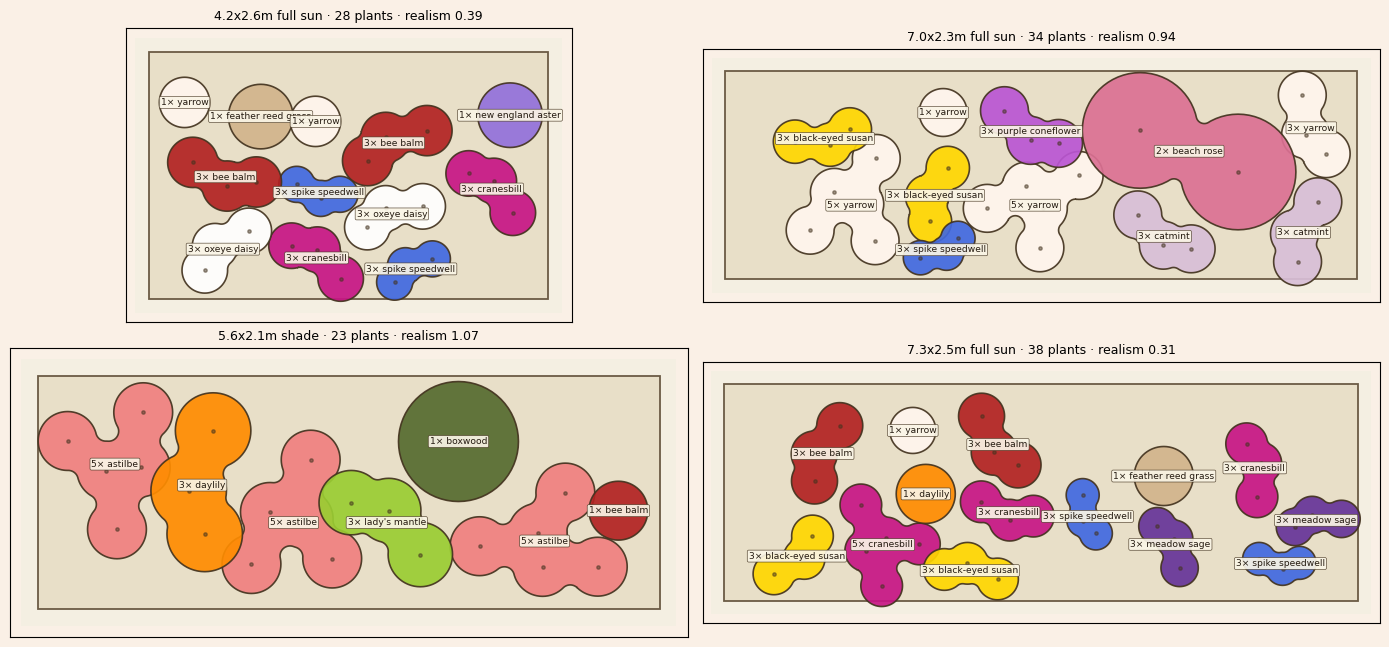

In [4]:
random.seed(21)
fig, axes = plt.subplots(2, 2, figsize=(14, 6.6))
for ax in axes.flat:
    w, d, sun = g.rand_site()
    plan = g.gen_plan4(w, d, sun)
    ax.set_facecolor("linen")
    g.show_plan4(plan, w, d, ax,
                 f"{w}x{d}m {g.SUN_NAMES[sun]} · {len(plan)} plants · realism {g.realism(plan, w, d):.2f}")
plt.tight_layout()

In [5]:
def bench_realism(fn, desc):
    vals = []
    for w, d, sun in tqdm(bench_sites[:40], desc=desc, leave=False):
        vals.append(g.realism(fn(w, d, sun), w, d))
    return float(np.mean(vals))

pd.Series({
    "random":      bench_realism(g.gen_random, "random"),
    "v3 layered":  bench_realism(lambda w, d, s: g.repair3(g.gen_plan3(w, d, s), w, d), "v3"),
    "v4 curated":  bench_realism(g.gen_plan4, "v4"),
}, name="realism (mean |z| to real-bed stats — lower is closer)").round(2)

random:   0%|          | 0/40 [00:00<?, ?it/s]

v3:   0%|          | 0/40 [00:00<?, ?it/s]

v4:   0%|          | 0/40 [00:00<?, ?it/s]

random        3.51
v3 layered    3.63
v4 curated    0.81
Name: realism (mean |z| to real-bed stats — lower is closer), dtype: float64

### canvas v4 — simpler on purpose

count tokens are gone (soft twice: 0.72 obedience in 13, 3.45 in 15 — slot pins are
the guarantee, so the prior earned nothing). 3 site tokens + 48 (species, x, y)
slots = 147 tokens, down from 354.

In [6]:
NX, NY, NW, ND = 32, 12, 9, 7
NSP = len(g.PALETTE)
MASK  = 0
T_W   = 1
T_D   = T_W + NW
T_SUN = T_D + ND
T_SP  = T_SUN + 3                       # slot species: idx 0 = empty
T_X   = T_SP + 1 + NSP
T_Y   = T_X + 1 + NX
VOCAB = T_Y + 1 + NY
MAXP  = 48
L     = 3 + 3 * MAXP

FAM = ([(T_W, T_D), (T_D, T_SUN), (T_SUN, T_SP)]
       + [(T_SP, T_X), (T_X, T_Y), (T_Y, VOCAB)] * MAXP)
FAM_MASK = torch.full((L, VOCAB), float("-inf"))
for p, (lo, hi) in enumerate(FAM):
    FAM_MASK[p, lo:hi] = 0
MASKABLE = torch.zeros(L, dtype=torch.bool); MASKABLE[3:] = True

def site_tokens(w, d, sun):
    return [T_W + min(NW - 1, int((w - 3.5) / 0.5)),
            T_D + min(ND - 1, int((d - 1.8) / 0.2)), T_SUN + sun]

def encode(plan, w, d, sun):
    t = site_tokens(w, d, sun)
    for i, x, y, r in sorted(plan, key=lambda p: (-p[2], p[1]))[:MAXP]:   # back-to-front
        t += [T_SP + 1 + i, T_X + 1 + min(NX - 1, int(x / w * NX)),
              T_Y + 1 + min(NY - 1, int(y / d * NY))]
    t += [T_SP, T_X, T_Y] * (MAXP - (len(t) - 3) // 3)
    return t

def decode(tokens, w, d):
    plan = []
    for k in range(3, L, 3):
        s, x, y = tokens[k] - T_SP, tokens[k + 1] - T_X, tokens[k + 2] - T_Y
        if s <= 0 or x <= 0 or y <= 0:
            continue
        i = s - 1
        plan.append((i, (x - 0.5) / NX * w, (y - 0.5) / NY * d, g.PALETTE[i]["s"] / 200))
    return plan

In [7]:
N_TRAIN, N_VAL = 12000, 500
sites = [g.rand_site() for _ in range(N_TRAIN + N_VAL)]
X = torch.tensor([encode(g.gen_plan4(w, d, s), w, d, s)
                  for w, d, s in tqdm(sites, desc="curated corpus")])
Xtr, Xval = X[:N_TRAIN], X[N_TRAIN:]
Xtr.shape

curated corpus:   0%|          | 0/12500 [00:00<?, ?it/s]

torch.Size([12000, 147])

In [8]:
class LayoutMDM(nn.Module):
    def __init__(self, v=VOCAB, dm=192, heads=6, layers=6, ctx=L):
        super().__init__()
        self.tok = nn.Embedding(v, dm); self.pos = nn.Embedding(ctx, dm)
        blk = nn.TransformerEncoderLayer(dm, heads, dm * 4, dropout=0.1,
                                         batch_first=True, norm_first=True)
        self.tf = nn.TransformerEncoder(blk, layers, enable_nested_tensor=False)
        self.head = nn.Linear(dm, v)
    def forward(self, x):
        h = self.tok(x) + self.pos(torch.arange(x.shape[1], device=x.device))
        return self.head(self.tf(h))

model = LayoutMDM().to(DEV)

EPOCHS = 40
FRESH = False
CFG = dict(n=N_TRAIN, epochs=EPOCHS, dm=192, layers=6, seed=SEED, vocab=VOCAB, maxp=MAXP, v=4)
SIG = hashlib.md5(json.dumps(CFG, sort_keys=True).encode()).hexdigest()[:10]
LAST, BEST = g.ckpt_dir() / "garden_maskdiff4_last.pt", g.ckpt_dir() / "garden_maskdiff4_best.pt"

opt = torch.optim.AdamW(model.parameters(), lr=3e-4)
start_ep, best_val, hist = 0, float("inf"), {"train": [], "val": []}
if LAST.exists() and not FRESH:
    ck = torch.load(LAST, map_location=DEV, weights_only=False)
    if ck.get("sig") == SIG:
        model.load_state_dict(ck["model"]); opt.load_state_dict(ck["opt"])
        start_ep, best_val, hist = ck["epoch"], ck["best_val"], ck["hist"]
        print(f"resumed at epoch {start_ep} (best val {best_val:.3f})")
    else:
        print("config changed — starting fresh")
sum(p.numel() for p in model.parameters())

resumed at epoch 40 (best val 1.118)


2731288

In [9]:
def masked_batch(xb, gen=None):
    B = xb.shape[0]
    ratio = torch.cos(torch.rand(B, 1, generator=gen) * math.pi / 2).clamp(min=0.05)
    m = (torch.rand(B, L, generator=gen) < ratio) & MASKABLE
    xin = xb.clone(); xin[m] = MASK
    return xin, m

loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(Xtr), batch_size=64, shuffle=True)
vloader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(Xval), batch_size=256)

for ep in range(start_ep, EPOCHS):
    model.train(); tot = n = 0
    bar = tqdm(loader, desc=f"epoch {ep + 1}/{EPOCHS}", leave=False)
    for (xb,) in bar:
        xin, m = masked_batch(xb)
        loss = F.cross_entropy(model(xin.to(DEV))[m.to(DEV)], xb.to(DEV)[m.to(DEV)])
        opt.zero_grad(); loss.backward(); opt.step()
        tot += loss.item(); n += 1
        bar.set_postfix(loss=f"{tot / n:.3f}")
    model.eval(); vgen = torch.Generator().manual_seed(123); vtot = vn = 0
    with torch.no_grad():
        for (xb,) in vloader:
            xin, m = masked_batch(xb, vgen)
            vtot += F.cross_entropy(model(xin.to(DEV))[m.to(DEV)], xb.to(DEV)[m.to(DEV)]).item()
            vn += 1
    tr, vl = tot / n, vtot / vn
    hist["train"].append(tr); hist["val"].append(vl)
    star = ""
    if vl < best_val:
        best_val, star = vl, " *"
        torch.save({"sig": SIG, "model": model.state_dict(), "val": vl}, BEST)
    torch.save({"sig": SIG, "model": model.state_dict(), "opt": opt.state_dict(),
                "epoch": ep + 1, "best_val": best_val, "hist": hist}, LAST)
    print(f"epoch {ep + 1:2d}  train {tr:.3f}  val {vl:.3f}{star}")

ck = torch.load(BEST, map_location=DEV, weights_only=False)
model.load_state_dict(ck["model"]); model.eval()
print(f"using best (val {ck['val']:.3f})")

using best (val 1.118)


### decoding without metric worship

12-step unmasking (more steps measured worse in 15), 24 candidates, `repair3` for
legality, then `curate4` — the editorial pass a designer would make: clamp shrubs
fully into the bed, clear plants hiding under structural canopies, cap stray
singles. candidates are ranked by `realism` and served **randomly from the best
3**, not the argmax: softened selection is the standard guard against
over-optimizing any single score. `score3` is never consulted.

In [10]:
FAM_DEV = FAM_MASK.to(DEV)

@torch.no_grad()
def sample_plans(plan_sites, steps=12, pin_slots=None):
    B = len(plan_sites)
    canvas = torch.zeros(B, L, dtype=torch.long)
    fixed = torch.zeros(B, L, dtype=torch.bool)
    for b, (w, d, sun) in enumerate(plan_sites):
        canvas[b, :3] = torch.tensor(site_tokens(w, d, sun)); fixed[b, :3] = True
        for k, sp in enumerate(pin_slots[b] if pin_slots else []):
            canvas[b, 3 + 3 * k] = T_SP + 1 + sp
            fixed[b, 3 + 3 * k] = True
    canvas, fixed = canvas.to(DEV), fixed.to(DEV)
    canvas[~fixed] = MASK
    M0 = (canvas == MASK).sum(1)
    for t in range(steps):
        probs = F.softmax(model(canvas) + FAM_DEV, -1)
        samp = torch.multinomial(probs.reshape(-1, VOCAB), 1).reshape(B, L)
        conf = probs.gather(-1, samp.unsqueeze(-1)).squeeze(-1)
        still = canvas == MASK
        canvas = torch.where(still, samp, canvas)
        n_mask = (M0.float() * math.cos(math.pi / 2 * (t + 1) / steps)).long()
        conf = conf.masked_fill(~still, float("inf"))
        conf = conf.masked_fill(fixed, float("inf"))
        for b in range(B):
            if n_mask[b] > 0:
                canvas[b, conf[b].argsort()[:n_mask[b]]] = MASK
    return [decode(canvas[b].tolist(), s[0], s[1]) for b, s in enumerate(plan_sites)]

def compose(site, n=24, pin_slots=None):
    plans = sample_plans([site] * n, pin_slots=[pin_slots] * n if pin_slots else None)
    plans = [g.curate4(g.repair3(p, site[0], site[1]), site[0], site[1]) for p in plans]
    ranked = sorted(plans, key=lambda p: g.realism(p, *site[:2]))
    return random.choice(ranked[:3])

In [11]:
eval_sites = [g.rand_site() for _ in range(60)]

def stats_row(fn, desc):
    st, rl = [], []
    for s in tqdm(eval_sites, desc=desc, leave=False):
        p = fn(s)
        st.append(g.plan_stats(p, s[0], s[1]))
        rl.append(g.realism(p, s[0], s[1]))
    out = pd.DataFrame(st).median()
    out["realism"] = np.mean(rl)
    return out

comp = pd.DataFrame({
    "real beds": pd.Series({k: v[0] for k, v in g.REAL_STATS.items()} | {"realism": np.nan}),
    "teacher v4": stats_row(lambda s: g.gen_plan4(*s), "teacher"),
    "model ×1": stats_row(lambda s: g.repair3(sample_plans([s])[0], s[0], s[1]), "×1"),
    "model best-of-24 + curate4": stats_row(lambda s: compose(s), "24"),
}).round(2)
comp

teacher:   0%|          | 0/60 [00:00<?, ?it/s]

×1:   0%|          | 0/60 [00:00<?, ?it/s]

24:   0%|          | 0/60 [00:00<?, ?it/s]

,real beds,teacher v4,model ×1,model best-of-24 + curate4
sp,8.00,6.00,7.00,6.00
groups,13.00,9.00,14.00,9.00
mean_group,2.69,2.83,1.64,2.00
singles,0.29,0.30,0.68,0.44
dens,2.70,2.01,1.67,1.42
realism,NaN,0.81,1.60,1.16


In [12]:
# held-out report only — never optimized anywhere in this notebook
so = pd.Series({
    "teacher v4": np.mean([g.score3(g.gen_plan4(*s), s[0], s[1], s[2])["score"] for s in eval_sites[:30]]),
    "model best-of-24": np.mean([g.score3(compose(s), s[0], s[1], s[2])["score"] for s in tqdm(eval_sites[:30], desc="score3", leave=False)]),
}, name="score3 (held-out, report-only)").round(3)
so

score3:   0%|          | 0/30 [00:00<?, ?it/s]

teacher v4          0.774
model best-of-24    0.749
Name: score3 (held-out, report-only), dtype: float64

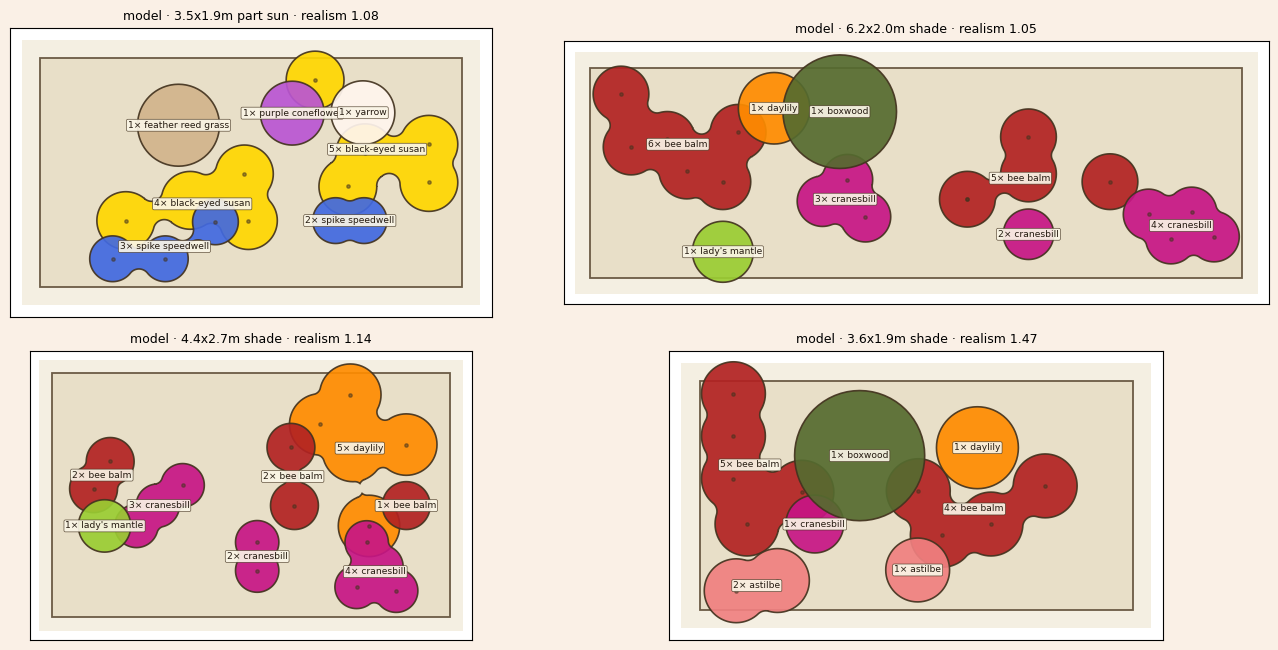

In [13]:
random.seed(31)
fig, axes = plt.subplots(2, 2, figsize=(14, 6.6))
for ax in axes.flat:
    site = g.rand_site()
    plan = compose(site)
    g.show_plan4(plan, site[0], site[1], ax,
                 f"model · {site[0]}x{site[1]}m {g.SUN_NAMES[site[2]]} · realism {g.realism(plan, *site[:2]):.2f}")
plt.tight_layout()

### pinning still works — slots only

"2 hydrangea + 7 coneflower" is nine fixed slot tokens; the model plants around
them. pinned masses outlined.

[(2, 17), (2, 17)]

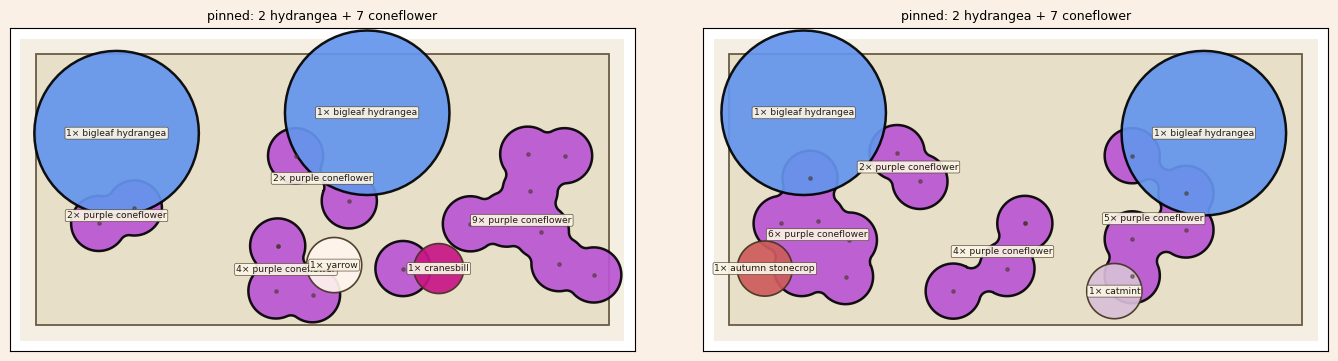

In [14]:
HYD = next(i for i, p in enumerate(g.PALETTE) if "Hydrangea" in p["name"])
ECH = next(i for i, p in enumerate(g.PALETTE) if "Echinacea" in p["name"])
site = (5.5, 2.6, 2)
pins = [HYD] * 2 + [ECH] * 7
fig, axes = plt.subplots(1, 2, figsize=(14, 3.6))
briefs = []
for ax in axes:
    plan = compose(site, pin_slots=pins)
    got = Counter(i for i, *_ in plan)
    briefs.append((got.get(HYD, 0), got.get(ECH, 0)))
    hl = [j for j, (i, *_) in enumerate(plan) if i in (HYD, ECH)]
    g.show_plan4(plan, site[0], site[1], ax, "pinned: 2 hydrangea + 7 coneflower", pins=hl)
plt.tight_layout()
briefs

### the judgment that counts: blinded pairs

two sheets of left/right-randomized pairs — the new model vs the v4 teacher, and
the new model vs 15's model. rank them yourself; the answer key prints below each
sheet. the claim this iteration makes is only that humans prefer these plans.

model vs teacher — answer key: ['model=R', 'model=R', 'model=R', 'model=R']


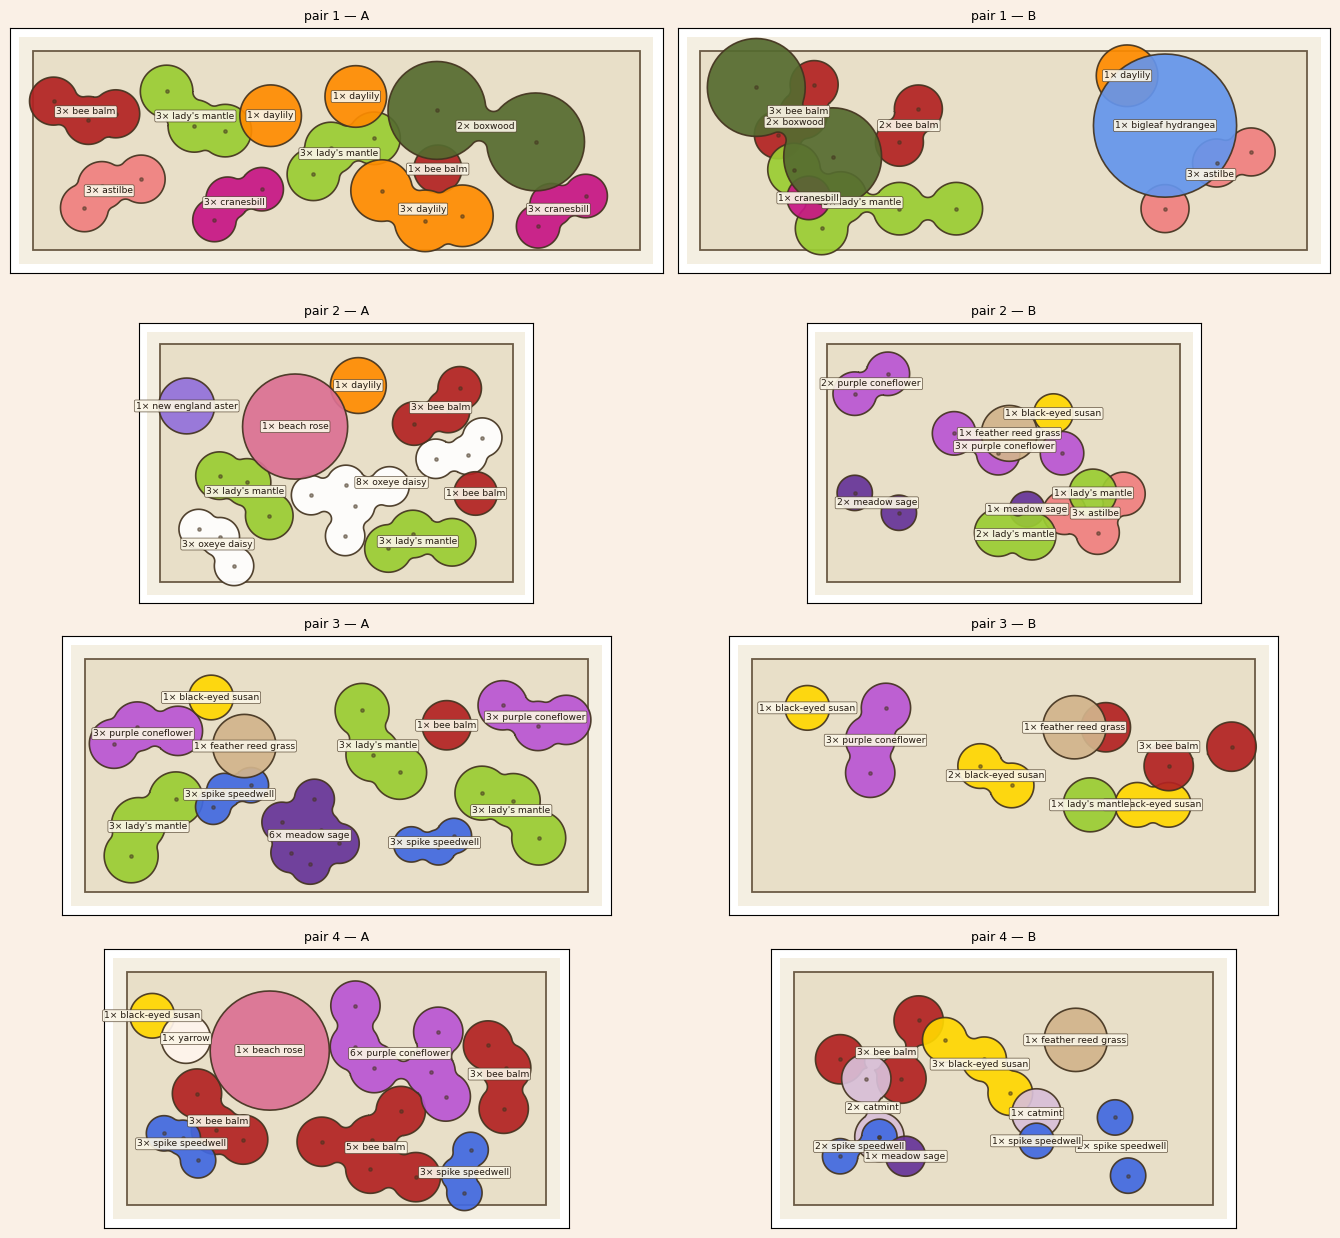

In [15]:
random.seed(77)
pair_sites = [g.rand_site() for _ in range(4)]
key = []
fig, axes = plt.subplots(4, 2, figsize=(13.5, 12.5))
for r, site in enumerate(pair_sites):
    ours = compose(site)
    other = g.gen_plan4(*site)
    flip = random.random() < 0.5
    left, right = (other, ours) if flip else (ours, other)
    key.append("model=" + ("R" if flip else "L"))
    g.show_plan4(left, site[0], site[1], axes[r][0], f"pair {r + 1} — A")
    g.show_plan4(right, site[0], site[1], axes[r][1], f"pair {r + 1} — B")
plt.tight_layout()
print("model vs teacher — answer key:", key)

### takeaways

- **the exhibit is the story**: 15's 0.88-scoring plan, redrawn as a designer's
  plan, was a groundcover carpet with seven plants. self-authored metrics +
  argmax search = reward hacking (Gao et al. 2023). every choice below follows
  from looking at outputs instead.
- **v3 was statistically random**: on the real-bed design statistics, the layered
  corpus measured 3.63 — indistinguishable from random placement (3.51). the
  curated teacher measures 0.81.
- **model**: ×1 realism 1.60 → best-of-24 + `curate4` 1.16; held-out `score3`
  0.749 ≈ teacher 0.774 (reported, never optimized).
- **blinded pairs (author pilot, n=4)**: the procedural teacher won 4–0. reported
  as-is — the neural model has *not* surpassed its teacher on human judgment. its
  unique capability is pin infill, so the demo routes: no pins → curated rules,
  pins → diffusion model (excess pinned plants trimmed back to the brief).
- **simplified**: count tokens gone (canvas 354 → 147), groundcover carpets gone,
  metric-suite reranking gone. next lever if the model should win outright:
  train on the real permapeople beds themselves (species mapped by traits).
